# 2020년 건강검진 일부 데이터 --> 산점도 그래프

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [2]:
# 데이터 불러오기
data = pd.read_excel('health_screenings_2020_1000ea.xlsx')

In [3]:
data.shape

(1000, 30)

In [4]:
data.head()

,year,city_code,gender,age_code,height,weight,waist,eye_left,eye_right,hear_left,...,serum,AST,ALT,GTP,smoking,drinking,oral_check,dental_caries,tartar,open_date
0,2020,36,1,9,165,60,72.1,1.2,1.5,1,...,1.1,21.0,27.0,21.0,1,0,0,NaN,NaN,2021-12-29
1,2020,27,2,13,150,65,81.0,0.8,0.8,1,...,0.5,18.0,15.0,15.0,1,0,0,NaN,NaN,2021-12-29
2,2020,11,2,12,155,55,70.0,0.6,0.7,1,...,0.7,27.0,25.0,7.0,1,0,0,NaN,NaN,2021-12-29
3,2020,31,1,13,160,70,90.8,1.0,1.0,1,...,1.2,65.0,97.0,72.0,1,0,1,0.0,0.0,2021-12-29
4,2020,41,2,12,155,50,75.2,1.5,1.2,1,...,0.7,18.0,17.0,14.0,1,0,0,NaN,NaN,2021-12-29


## 키, 몸무게 데이터를 가지고 산점도 그래프 그리기

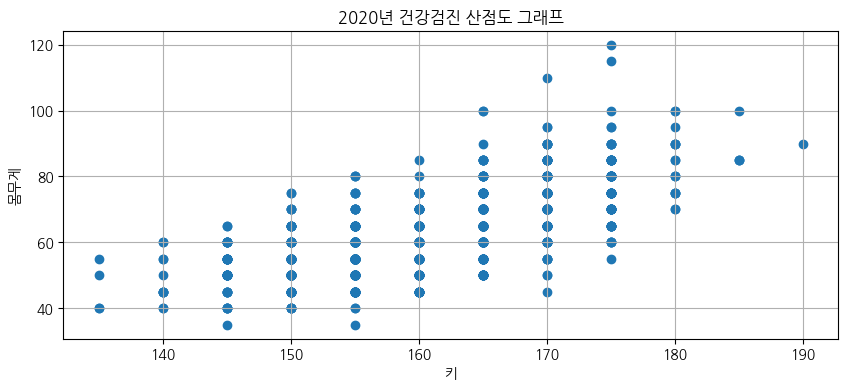

In [5]:
heightdata = data['height'] #키
weightdata = data['weight'] #몸무게

plt.figure(figsize=(10,4))               # 배경크기
plt.scatter(x=heightdata, y=weightdata)  # scatter --> 산점도그래프
plt.title('2020년 건강검진 산점도 그래프')
plt.xlabel('키')
plt.ylabel('몸무게')
plt.grid() 
plt.show()

## [수축기 혈압, 이완기 혈압, 공복 혈당] 그룹 산점도

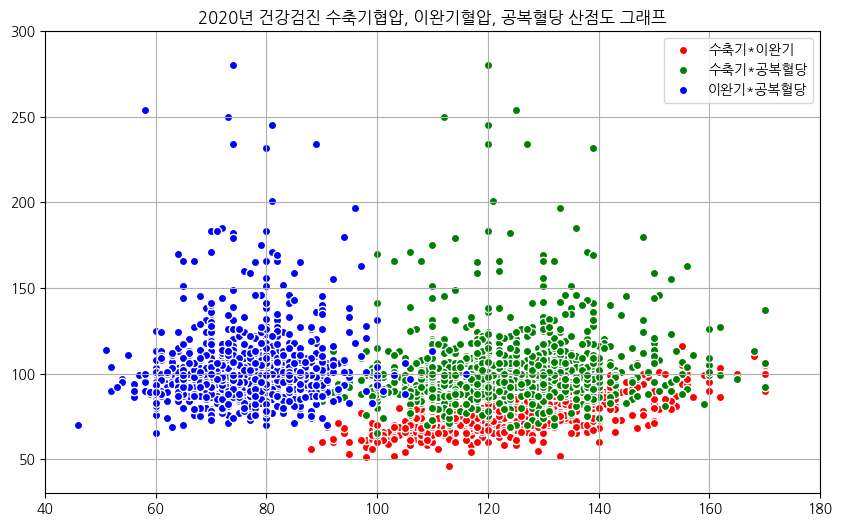

In [6]:
systolic_data = data['systolic']        # 수축기 혈압
diastolic_data = data['diastolic']     #이완기 혈압
blood_sugar_data = data['blood_sugar']  # 공복 혈당

plt.figure(figsize=(10,6))               # 배경크기

plt.scatter(x=systolic_data, y=diastolic_data, color='r', edgecolor='w', label='수축기*이완기')   #edgecolor -->  점 가장자리 색, w-->white
plt.scatter(x=systolic_data, y=blood_sugar_data, color='g', edgecolor='w', label='수축기*공복혈당')
plt.scatter(x=diastolic_data, y=blood_sugar_data, color='b', edgecolor='w', label='이완기*공복혈당')
plt.title('2020년 건강검진 수축기협압, 이완기혈압, 공복혈당 산점도 그래프')
plt.xlim(40, 180)
plt.ylim(30, 300)
plt.legend()
plt.grid() 
plt.show()


## 여성 키 히스토그램

In [7]:
fe=data['gender']==2
fe.head()


0    False
1     True
2     True
3    False
4     True
Name: gender, dtype: bool

In [8]:
fe1=data.loc[data.gender==2,['gender','height']]
fe1.head()

,gender,height
1,2,150
2,2,155
4,2,155
8,2,150
9,2,150


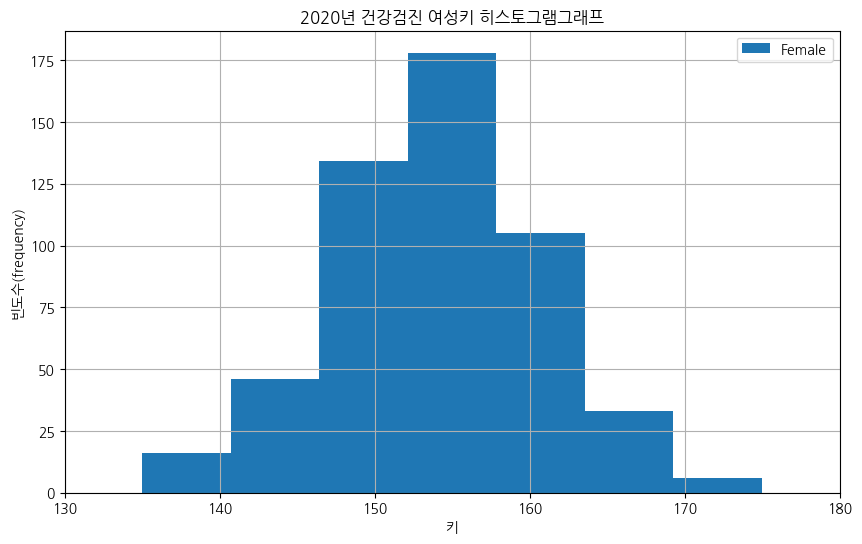

In [9]:

female_data = data.loc[data.gender==2, ['gender','height']]
plt.figure(figsize=(10,6))               # 배경크기

plt.hist(x=female_data['height'], bins=7, label='Female') 

plt.title('2020년 건강검진 여성키 히스토그램그래프')
plt.xlim(130, 180)
plt.xlabel('키')
plt.ylabel('빈도수(frequency)')
plt.legend()
plt.grid() 
plt.show()

## 남성, 여성 키 그룹 히스토그램

In [10]:
male=data['gender']==1 #남성은 1

male_data = data.loc[male, ['gender','height']]
male_data.head()

,gender,height
0,1,165
3,1,160
5,1,185
6,1,165
7,1,160


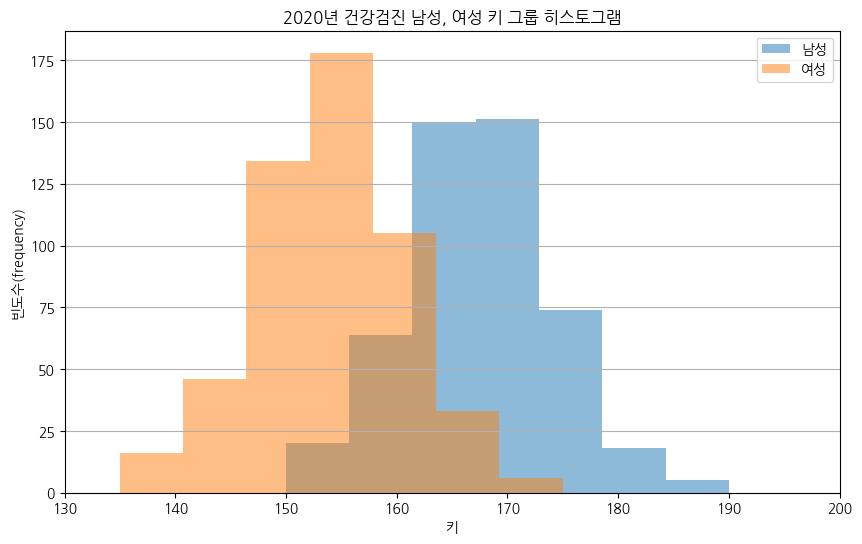

In [19]:
plt.figure(figsize=(10,6))
plt.hist(male_data['height'], bins=7, alpha=0.5, label='남성') #alpha -->  투명도가 50%
plt.hist(female_data['height'], bins=7, alpha=0.5, label='여성') # bins --> 막대길이(높이)
plt.title('2020년 건강검진 남성, 여성 키 그룹 히스토그램')
plt.xlim(130, 200)
plt.xlabel('키')
plt.ylabel('빈도수(frequency)')
plt.legend()
plt.grid(axis='y')
plt.show()

## 남성, 여성 키 상자수염 그래프

In [12]:
female_data['height'].head()

1    150
2    155
4    155
8    150
9    150
Name: height, dtype: int64

In [13]:
male_data['height'].head()

0    165
3    160
5    185
6    165
7    160
Name: height, dtype: int64

In [14]:
import numpy as np

# 배열
height = np.array([male_data['height'], female_data['height']], dtype=object)
height

array([0      165
       3      160
       5      185
       6      165
       7      160
             ...
       991    160
       994    160
       995    165
       996    165
       999    160
       Name: height, Length: 482, dtype: int64,
       1      150
       2      155
       4      155
       8      150
       9      150
             ...
       990    150
       992    150
       993    145
       997    155
       998    150
       Name: height, Length: 518, dtype: int64], dtype=object)

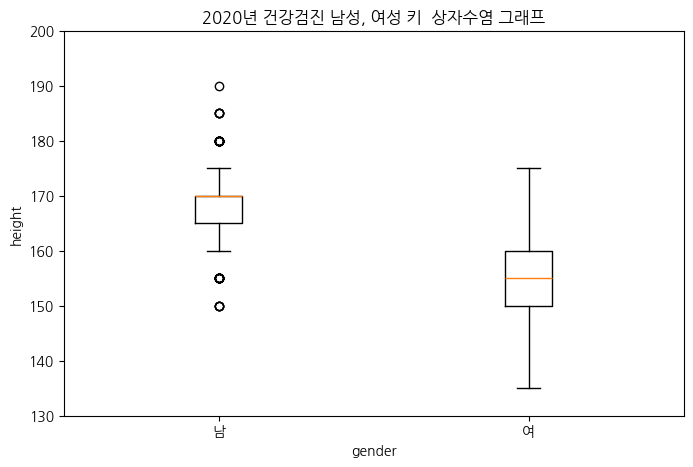

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(height,  tick_labels=['남','여'])

plt.title('2020년 건강검진 남성, 여성 키  상자수염 그래프')
plt.ylim(130, 200)
plt.xlabel('키')
plt.ylabel('몸무게')

plt.show()